# Step 7 : Tuning and Stacking

In [3]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.metrics import f1_score, confusion_matrix, classification_report

In [4]:
filepath = r'dataset/weekly_btc_2017_2026.csv'
theme_color = ['#36827F','#464D77','#F9DB6D','#F4EDED','#877666'] 

In [5]:
df = pd.read_csv(filepath, index_col= 'Unnamed: 0')
df.index = pd.to_datetime(df.index) 
df.sort_index(ascending = True, inplace=True)

In [6]:
df = df.drop(columns = ['pct_change_1w','pct_change_4w','pct_change_8w'])

In [7]:
df.head(3)

,Sentiment,Open,High,Low,Close,Volume,year,month,quarter,weekno
2017-01-06,0.036157,963.658020,1191.099976,883.943970,902.200989,1762148992,2017,1,1,1
2017-01-13,-0.038909,903.487000,942.723999,755.755981,823.984009,1398173008,2017,1,1,2
2017-01-20,-0.075130,825.142029,917.499023,812.455994,895.026001,819957496,2017,1,1,3


In [8]:
df.index.to_series().rename('date').agg(['min', 'max'])

min   2017-01-06
max   2026-04-17
Name: date, dtype: datetime64[ns]

## Target Column Creation

In [9]:
df['r1'] = df['Close'].pct_change(periods = 1)

In [10]:
# Binary classess with threshold 
upper_threshold = 0.01
lower_threshold = -0.01

mask = (df['r1'] > upper_threshold) | (df['r1'] < lower_threshold) 

print("Kept:", mask.sum())
print("Dropped neutral:", (~mask).sum())
print("Kept %:", mask.mean())

df = df.loc[mask].copy()
df['label_q'] = (df.loc[mask, 'r1'] > upper_threshold).astype(int) # uptrend is 1 , downtrend is 0

Kept: 417
Dropped neutral: 68
Kept %: 0.8597938144329897


## Feature Engeeneering

In [11]:
EPS = 1e-8

# Compute r1
df['r1'] = df['Close'].pct_change(1) 

# compute lag r1 
for lag in [2,4,8,12]:
    df[f"r1_lag{lag}"] = df['r1'].shift(lag) 

# Compute lag multi-Horizon return then lag 
for k in [2,4,8,12]:
    df[f"r{k}_lag1"] = df["Close"].pct_change(k).shift(1)

# Compute Volatility/momentum on weekly log returns then lag 
for w in [2,4,8,12]:
    df[f"vol_{w}w_lag1"] = df["r1"].rolling(w).std().shift(1)
    df[f"mom_{w}w_lag1"] = df["r1"].rolling(w).mean().shift(1) 

# compute high-low range 
df["hl_range"] = (df["High"] - df["Low"]) / (df["Close"] + EPS)

for w in [2,4,8,12]:
    df[f"hl_range_mean_{w}_lag1"] = df["hl_range"].rolling(w).mean().shift(1)
    df[f"hl_range_std_{w}_lag1"] = df["hl_range"].rolling(w).std().shift(1) 

# ---- Trend ---
for w in [2,4,8,12]:
    ma = df["Close"].rolling(w).mean()
    df[f"close_to_ma_{w}_lag1"] = ((df["Close"] - ma) / (ma + EPS)).shift(1)
    df[f"ma_slope_{w}_lag1"] = ma.diff().shift(1)

# --- Volume ---
df["dollar_volume_lag1"] = (df["Close"] * df["Volume"]).shift(1)
df["volume_change_1_lag1"] = df["Volume"].pct_change().shift(1)

for w in [2,4,8,12]:
    vol_mu = df["Volume"].rolling(w).mean()
    vol_sd = df["Volume"].rolling(w).std()
    
    df[f"vol_ratio_{w}_lag1"] = (df["Volume"] / (vol_mu + EPS)).shift(1)
    df[f"vol_z_{w}_lag1"] = ((df["Volume"] - vol_mu) / (vol_sd + EPS)).shift(1)

# Define RSI function
def rsi_wilder(close: pd.Series, period: int = 14) -> pd.Series:
    delta = close.diff()
    gain = delta.clip(lower=0)
    loss = (-delta).clip(lower=0)

    avg_gain = gain.ewm(alpha=1/period, adjust=False, min_periods=period).mean()
    avg_loss = loss.ewm(alpha=1/period, adjust=False, min_periods=period).mean()

    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

for p in [4,8,12]:
    df[f"RSI_{p}w"] = rsi_wilder(df["Close"], p)
    df[f"RSI_{p}w_lag1"] = df[f"RSI_{p}w"].shift(1)


# sentiment features engineering 
df["sentiment_lag_1"] = df["Sentiment"].shift(1)
df["sentiment_chg_1_lag1"] = df["Sentiment"].diff(1).shift(1)
df["sentiment_chg_2_lag1"] = df["Sentiment"].diff(2).shift(1) 

# rolling sentiment 
for w in [4,8]:
    df[f"s_mean_{w}_lag1"] = df["Sentiment"].rolling(w).mean().shift(1)
    df[f"s_std_{w}_lag1"]  = df["Sentiment"].rolling(w).std().shift(1) 

# extreme sentiment features 
z = (df["Sentiment"] - df["Sentiment"].rolling(8).mean()) / df["Sentiment"].rolling(8).std()
df["sentiment_z8_lag1"] = z.shift(1)

# x momentum features 
df['sentiment_x_momentum_lag1'] = df['sentiment_lag_1'] * df['mom_4w_lag1']
df['rsi_x_sentiment_lag1'] = df['RSI_4w_lag1'] *df['sentiment_lag_1'] 
df['sentiment_x_trend_lag1'] = df['sentiment_lag_1'] * df['close_to_ma_4_lag1']

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 417 entries, 2017-01-13 to 2026-04-17
Data columns (total 72 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Sentiment                  417 non-null    float64
 1   Open                       417 non-null    float64
 2   High                       417 non-null    float64
 3   Low                        417 non-null    float64
 4   Close                      417 non-null    float64
 5   Volume                     417 non-null    int64  
 6   year                       417 non-null    int64  
 7   month                      417 non-null    int64  
 8   quarter                    417 non-null    int64  
 9   weekno                     417 non-null    int64  
 10  r1                         416 non-null    float64
 11  label_q                    417 non-null    int64  
 12  r1_lag2                    414 non-null    float64
 13  r1_lag4                    412 

In [27]:
import numpy as np
import pandas as pd

from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import  HistGradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, balanced_accuracy_score

from xgboost import XGBClassifier

In [14]:
# --- 1) Define columns set for different scenario ---
price_cols = [    
    # --- Returns / momentum ---
    'r1_lag2',
    'r1_lag8',
    'r1_lag12',
    'r4_lag1',

    # --- Volatility ---
    'vol_4w_lag1',
    'mom_4w_lag1',
    'vol_12w_lag1',
    'mom_12w_lag1',
    'hl_range_std_4_lag1',
    'hl_range_std_12_lag1',

    # --- Trend ---
    'close_to_ma_4_lag1',
    'ma_slope_4_lag1',
    'close_to_ma_8_lag1',
    'ma_slope_8_lag1',
    
    # --- Volume ---
    'dollar_volume_lag1',
    'volume_change_1_lag1',
    'vol_z_4_lag1',
    'vol_z_8_lag1',
    'vol_z_12_lag1',
    
    # --- RSI ---
    'RSI_4w_lag1',
    'RSI_8w_lag1',
    'RSI_12w_lag1',

] 

sent_cols = [
     # --- Sentiment ---
    'sentiment_lag_1',
    'sentiment_chg_1_lag1',
    'sentiment_chg_2_lag1',
    's_mean_4_lag1',
    's_std_4_lag1',
    's_mean_8_lag1',
    's_std_8_lag1',
    'sentiment_z8_lag1',
    'sentiment_x_momentum_lag1',
    'rsi_x_sentiment_lag1',
    'sentiment_x_trend_lag1'  
]

X_sets = {
    "price_only": price_cols,
    "sent_only": sent_cols,
    "combined": price_cols + sent_cols,      
} 

### XGBoost Hyperparameter Tuning with Combined Features

In [15]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from xgboost import XGBClassifier
import time  

# Prepare data 
df_model = df.copy().sort_index()   # or sort_values("date") if you have a date column
df_model = df_model.dropna(subset=price_cols + sent_cols + ["label_q"])  # simplest

# Prepare combined features data
X_combined = df_model[price_cols + sent_cols]
y_combined = df_model["label_q"].astype(int)

print(f"Combined feature set shape: {X_combined.shape}")
print(f"Target distribution:\n{y_combined.value_counts().sort_index()}")

Combined feature set shape: (404, 33)
Target distribution:
label_q
0    183
1    221
Name: count, dtype: int64


In [16]:
# time series split for cross-validation 
tscv = TimeSeriesSplit(n_splits=5)

# Define parameter grid for hyperparameter tuning
param_grid = {
    'max_depth': [3, 4, 5, 6, 7],
    'learning_rate': [0.01, 0.05, 0.1, 0.15],
    'n_estimators': [100, 200, 300, 400],
    'subsample': [0.6, 0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9],
    'gamma': [0, 1, 2, 3],
    'min_child_weight': [1, 2, 3],
}

# Create base XGBoost classifier (BINARY classification)
xgb_base = XGBClassifier(
    objective='binary:logistic',
    random_state=42,
    eval_metric='logloss',
    tree_method='hist',
    verbosity=0
)

# Use RandomizedSearchCV for faster tuning (GridSearch would be too slow)
print("Starting RandomizedSearchCV for XGBoost hyperparameter tuning...")
print("This may take a few minutes...\n")

xgb_search = RandomizedSearchCV(
    xgb_base,
    param_distributions=param_grid,
    n_iter=50,  # Number of combinations to try
    cv=tscv,  # Use TimeSeriesSplit for proper cross-validation
    scoring='balanced_accuracy',  # Primary metric
    n_jobs=-1,  # Use all available cores
    verbose=1,
    random_state=42
)

start_time = time.time()
xgb_search.fit(X_combined, y_combined)
elapsed_time = time.time() - start_time

print(f"\n✓ Hyperparameter tuning completed in {elapsed_time/60:.2f} minutes")
print(f"\nBest parameters: {xgb_search.best_params_}")
print(f"Best balanced accuracy score: {xgb_search.best_score_:.4f}")

Starting RandomizedSearchCV for XGBoost hyperparameter tuning...
This may take a few minutes...

Fitting 5 folds for each of 50 candidates, totalling 250 fits

✓ Hyperparameter tuning completed in 0.18 minutes

Best parameters: {'subsample': 0.7, 'n_estimators': 400, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 0.6}
Best balanced accuracy score: 0.5426


In [17]:
# Display top 10 parameter combinations
results_df = pd.DataFrame(xgb_search.cv_results_)
results_df = results_df[['param_max_depth', 'param_learning_rate', 'param_n_estimators', 
                          'param_subsample', 'param_colsample_bytree', 'param_gamma', 
                          'param_min_child_weight', 'mean_test_score', 'std_test_score']].sort_values(
                          'mean_test_score', ascending=False)

print("Top 10 Parameter Combinations:")
print("="*120)
print(results_df.head(10).to_string(index=False))
print("="*120)


Top 10 Parameter Combinations:
 param_max_depth  param_learning_rate  param_n_estimators  param_subsample  param_colsample_bytree  param_gamma  param_min_child_weight  mean_test_score  std_test_score
               6                 0.01                 400              0.7                     0.6            0                       3         0.542581        0.047758
               3                 0.15                 200              0.6                     0.8            3                       1         0.539174        0.047796
               6                 0.10                 400              0.6                     0.7            2                       1         0.538196        0.047191
               4                 0.10                 300              0.6                     0.8            3                       1         0.537988        0.061440
               7                 0.05                 400              0.6                     0.9            0             

In [18]:
# Train final model with best parameters on full training data
best_xgb = xgb_search.best_estimator_

print("\n" + "="*80)
print("TRAINING FINAL XGBoost MODEL WITH BEST PARAMETERS")
print("="*80)

# Split data for final evaluation
from sklearn.model_selection import train_test_split

# For time series, use temporal split
train_size = int(0.8 * len(X_combined))
X_train_final = X_combined.iloc[:train_size]
y_train_final = y_combined.iloc[:train_size]
X_test_final = X_combined.iloc[train_size:]
y_test_final = y_combined.iloc[train_size:]

# Train on full training set
best_xgb.fit(X_train_final, y_train_final)

# Make predictions
y_pred_final = best_xgb.predict(X_test_final)

print("\n✓ Model Training Complete!")
print(f"Training set size: {X_train_final.shape[0]} samples")
print(f"Test set size: {X_test_final.shape[0]} samples")


TRAINING FINAL XGBoost MODEL WITH BEST PARAMETERS

✓ Model Training Complete!
Training set size: 323 samples
Test set size: 81 samples



FINAL XGBoost MODEL PERFORMANCE (Combined Features)

Test Accuracy: 0.5185
Balanced Accuracy: 0.5152
Macro F1-Score: 0.4802
Weighted F1-Score: 0.4819

Confusion Matrix:
[[32  9]
 [30 10]]

Classification Report:
               precision    recall  f1-score   support

Downtrend (0)       0.52      0.78      0.62        41
  Uptrend (1)       0.53      0.25      0.34        40

     accuracy                           0.52        81
    macro avg       0.52      0.52      0.48        81
 weighted avg       0.52      0.52      0.48        81



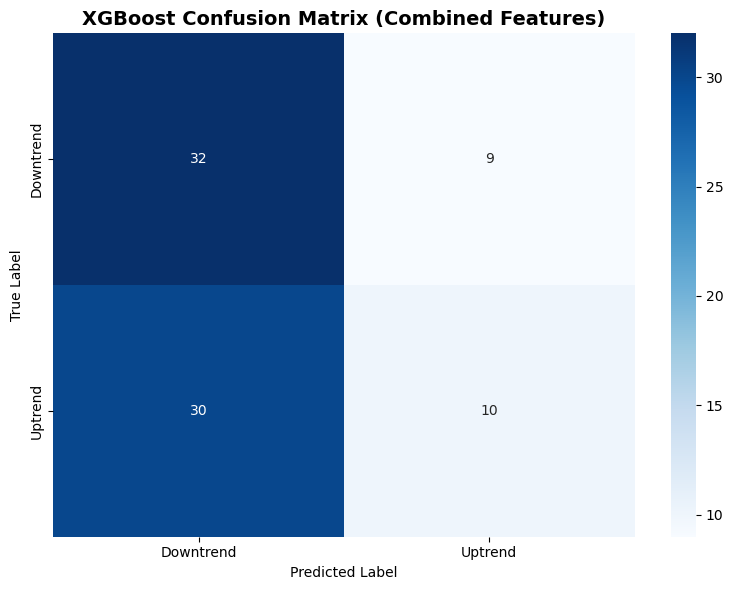

In [19]:
# Evaluate tuned XGBoost model
print("\n" + "="*80)
print("FINAL XGBoost MODEL PERFORMANCE (Combined Features)")
print("="*80)

print(f"\nTest Accuracy: {accuracy_score(y_test_final, y_pred_final):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test_final, y_pred_final):.4f}")
print(f"Macro F1-Score: {f1_score(y_test_final, y_pred_final, average='macro'):.4f}")
print(f"Weighted F1-Score: {f1_score(y_test_final, y_pred_final, average='weighted'):.4f}")

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test_final, y_pred_final, labels=[0, 1])
print(cm)

print("\nClassification Report:")
print(classification_report(y_test_final, y_pred_final, 
                          target_names=['Downtrend (0)', 'Uptrend (1)']))

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['Downtrend', 'Uptrend'],
            yticklabels=['Downtrend', 'Uptrend'])
plt.title('XGBoost Confusion Matrix (Combined Features)', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

                   feature  importance
13         ma_slope_8_lag1    0.036711
2                 r1_lag12    0.036308
31    rsi_x_sentiment_lag1    0.036281
5              mom_4w_lag1    0.036264
3                  r4_lag1    0.034917
19             RSI_4w_lag1    0.034844
25           s_mean_4_lag1    0.034713
12      close_to_ma_8_lag1    0.033456
23    sentiment_chg_1_lag1    0.033314
28            s_std_8_lag1    0.032956
1                  r1_lag8    0.032415
11         ma_slope_4_lag1    0.032257
16            vol_z_4_lag1    0.031326
21            RSI_12w_lag1    0.031315
4              vol_4w_lag1    0.031168
14      dollar_volume_lag1    0.030919
10      close_to_ma_4_lag1    0.030830
7             mom_12w_lag1    0.030525
20             RSI_8w_lag1    0.030375
15    volume_change_1_lag1    0.028658
8      hl_range_std_4_lag1    0.027774
17            vol_z_8_lag1    0.027685
27           s_mean_8_lag1    0.027369
32  sentiment_x_trend_lag1    0.027210
22         sentiment_lag_

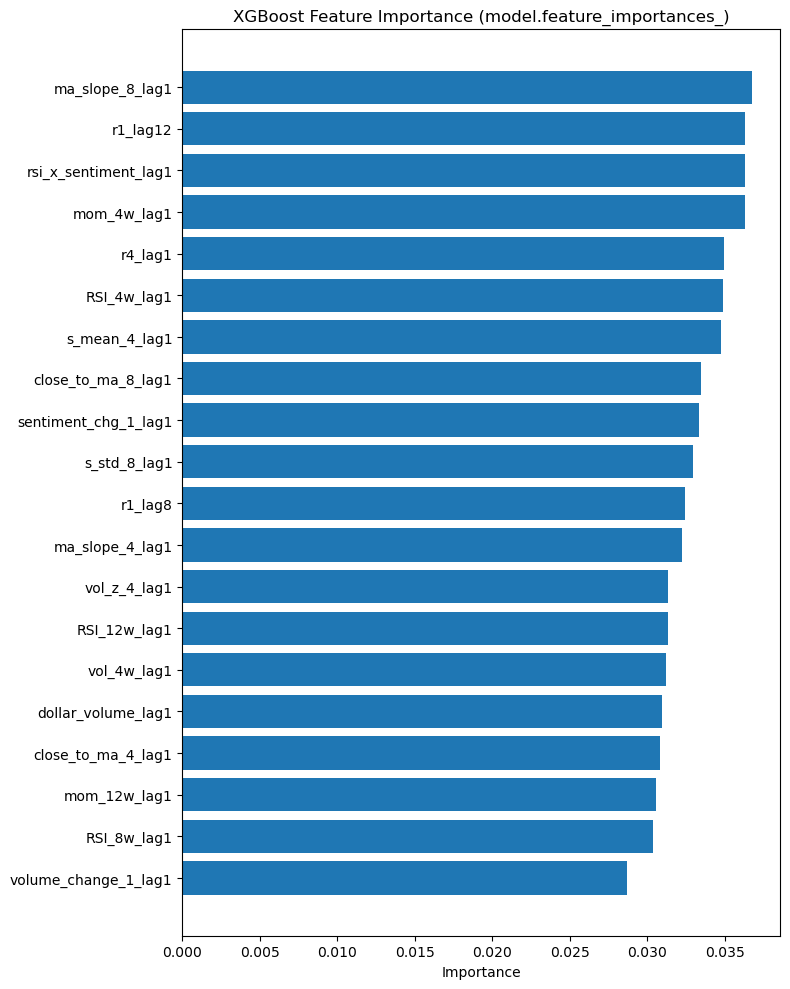

In [20]:
# model is your fitted XGBClassifier/XGBRegressor
# X_train is your training DataFrame (preferred) or numpy array

feature_names = getattr(X_train_final, "columns", None)
importances = best_xgb.feature_importances_

fi = pd.DataFrame({
    "feature": feature_names if feature_names is not None else [f"f{i}" for i in range(len(importances))],
    "importance": importances
}).sort_values("importance", ascending=False)

print(fi.head(30))

plt.figure(figsize=(8, 10))
plt.barh(fi["feature"].head(20)[::-1], fi["importance"].head(20)[::-1])
plt.title("XGBoost Feature Importance (model.feature_importances_)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## High Gradient Boosting

In [28]:
# HistGradientBoostingClassifier Hyperparameter Tuning with Combined Features
print("HistGradientBoostingClassifier Hyperparameter Tuning with Combined Features")
print("="*80)
print(f"Combined feature set shape: {X_combined.shape}")
print(f"Target distribution:\n{y_combined.value_counts().sort_index()}")


HistGradientBoostingClassifier Hyperparameter Tuning with Combined Features
Combined feature set shape: (404, 33)
Target distribution:
label_q
0    183
1    221
Name: count, dtype: int64


In [32]:
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.ensemble import HistGradientBoostingClassifier
import time

# Time series split for cross-validation
tscv = TimeSeriesSplit(n_splits=5)

# Define parameter grid for hyperparameter tuning
histgb_param_grid = {
    'max_depth': [4, 5, 6, 7, 8],
    'learning_rate': [0.001, 0.01, 0.05, 0.1, 0.15],
    'max_iter': [100, 200, 300, 400, 500],
    'max_leaf_nodes': [20, 31, 50, 100],
    'min_samples_leaf': [5, 10, 20],
    'l2_regularization': [0.0, 0.01, 0.1, 1.0],
    'max_features': [0.5, 0.7, 1.0],
}

# Create base HistGradientBoostingClassifier
histgb_base = HistGradientBoostingClassifier(
    loss='log_loss',  # Correct for binary classification
    early_stopping=False,
    random_state=42,
    verbose=False,
)

# Use RandomizedSearchCV for faster tuning
print("\nStarting RandomizedSearchCV for HistGradientBoostingClassifier hyperparameter tuning...")
print("This may take a few minutes...\n")

histgb_search = RandomizedSearchCV(
    histgb_base,
    param_distributions=histgb_param_grid,
    n_iter=50,  # Number of combinations to try
    cv=tscv,  # Use TimeSeriesSplit for proper cross-validation
    scoring='balanced_accuracy',  # Primary metric
    n_jobs=-1,  # Use all available cores
    verbose=1,
    random_state=42
)

start_time = time.time()
histgb_search.fit(X_combined, y_combined)
elapsed_time = time.time() - start_time

print(f"\n✓ HistGradientBoosting hyperparameter tuning completed in {elapsed_time/60:.2f} minutes")
print(f"\nBest parameters: {histgb_search.best_params_}")
print(f"Best balanced accuracy score: {histgb_search.best_score_:.4f}")



Starting RandomizedSearchCV for HistGradientBoostingClassifier hyperparameter tuning...
This may take a few minutes...

Fitting 5 folds for each of 50 candidates, totalling 250 fits

✓ HistGradientBoosting hyperparameter tuning completed in 0.12 minutes

Best parameters: {'min_samples_leaf': 20, 'max_leaf_nodes': 31, 'max_iter': 100, 'max_features': 1.0, 'max_depth': 5, 'learning_rate': 0.1, 'l2_regularization': 0.0}
Best balanced accuracy score: 0.5414


In [34]:
# Display top 10 parameter combinations for HistGradientBoostingClassifier
histgb_results_df = pd.DataFrame(histgb_search.cv_results_)
histgb_results_df = histgb_results_df[['param_max_depth', 'param_learning_rate', 'param_max_iter',
                                        'param_max_leaf_nodes', 'param_min_samples_leaf', 'param_l2_regularization',
                                        'param_max_features',
                                        'mean_test_score', 'std_test_score']].sort_values(
                                        'mean_test_score', ascending=False)

print("Top 10 HistGradientBoosting Parameter Combinations:")
print("="*150)
print(histgb_results_df.head(10).to_string(index=False))
print("="*150)

Top 10 HistGradientBoosting Parameter Combinations:
 param_max_depth  param_learning_rate  param_max_iter  param_max_leaf_nodes  param_min_samples_leaf  param_l2_regularization  param_max_features  mean_test_score  std_test_score
               5                 0.10             100                    31                      20                     0.00                 1.0         0.541437        0.070489
               7                 0.10             500                    20                      20                     1.00                 0.7         0.540244        0.045873
               4                 0.15             500                   100                      20                     1.00                 0.5         0.532539        0.028369
               8                 0.15             300                    50                      20                     1.00                 0.7         0.532011        0.073975
               4                 0.01             200     

In [35]:
# Train final HistGradientBoosting model with best parameters
best_histgb = histgb_search.best_estimator_

print("\n" + "="*80)
print("TRAINING FINAL HistGradientBoosting MODEL WITH BEST PARAMETERS")
print("="*80)

# Use the same temporal split as XGBoost and CatBoost
best_histgb.fit(X_train_final, y_train_final)

# Make predictions
y_pred_histgb = best_histgb.predict(X_test_final)
y_pred_proba_histgb = best_histgb.predict_proba(X_test_final)[:, 1]

print("\n✓ HistGradientBoosting Model Training Complete!")
print(f"Training set size: {X_train_final.shape[0]} samples")
print(f"Test set size: {X_test_final.shape[0]} samples")



TRAINING FINAL HistGradientBoosting MODEL WITH BEST PARAMETERS

✓ HistGradientBoosting Model Training Complete!
Training set size: 323 samples
Test set size: 81 samples


In [42]:
print("\n" + "="*80)
print("COMPARISON: XGBoost vs HistGradientBoosting (Combined Features)")
print("="*80)

comparison_all = pd.DataFrame({
    'Metric': ['Accuracy', 'Balanced Accuracy', 'Macro F1-Score', 'Weighted F1-Score'],
    'XGBoost': [
        accuracy_score(y_test_final, y_pred_final),
        balanced_accuracy_score(y_test_final, y_pred_final),
        f1_score(y_test_final, y_pred_final, average='macro'),
        f1_score(y_test_final, y_pred_final, average='weighted')
    ],
    'HistGradientBoosting': [
        accuracy_score(y_test_final, y_pred_histgb),
        balanced_accuracy_score(y_test_final, y_pred_histgb),
        f1_score(y_test_final, y_pred_histgb, average='macro'),
        f1_score(y_test_final, y_pred_histgb, average='weighted')
    ]
})

print("\n", comparison_all.to_string(index=False))


COMPARISON: XGBoost vs HistGradientBoosting (Combined Features)

            Metric  XGBoost  HistGradientBoosting
         Accuracy 0.518519              0.530864
Balanced Accuracy 0.515244              0.526829
   Macro F1-Score 0.480171              0.472222
Weighted F1-Score 0.481914              0.474394
